# Project 1: AI Adoption, Trust & Institutional Clarity Analysis

**Exploratory Data Analysis | Python · SQL · pandas · matplotlib · seaborn**

This project analyzes original survey data collected as part of undergraduate research at the University of Toronto Mississauga. While the dataset comes from an academic setting, the analysis is framed around a business-style problem: **how users adopt a new technology, how trust develops, and how communication gaps shape behavior.**

**Business-style question:**  
When a new tool becomes widely available, what drives adoption, trust, confusion, and perceived value among different user segments?

In [1]:
import os
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 1. Load the Data

The workbook contains four sheets. The analysis uses the **Raw Data** sheet as the source of truth.

In [2]:
possible_paths = [
    Path("AI_Survey_Clean_Data.xlsx"),
    Path("AI_Survey_Clean_Data (1).xlsx"),
    Path("/mnt/data/AI_Survey_Clean_Data (1).xlsx"),
    Path("/mnt/data/AI_Survey_Clean_Data.xlsx"),
]

DATA_PATH = next((path for path in possible_paths if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Could not find the Excel file. Place AI_Survey_Clean_Data.xlsx in this folder.")

raw = pd.read_excel(DATA_PATH, sheet_name="Raw Data")
summary_by_program = pd.read_excel(DATA_PATH, sheet_name="Summary by Program")
data_dictionary = pd.read_excel(DATA_PATH, sheet_name="Data Dictionary")

print(f"Data source: {DATA_PATH}")
print(f"Rows: {raw.shape[0]}, Columns: {raw.shape[1]}")
raw.head()

Data source: AI_Survey_Clean_Data (1).xlsx
Rows: 86, Columns: 13


,#,Program,Living Situation,AI Frequency,Tools Used,Uses,Confidence,Trust,Guideline Clarity,Instructor Guidance,Learning Impact,Preparedness,Independence
0,1,Commerce/Management,Off campus within Mississauga,Daily,"ChatGPT, Grammarly","Brainstorming, clarifying concepts, writing as...",Very confident,Trustworthy,Somewhat unclear,"No, never","Yes, mostly positive",Prepared,Somewhat supports
1,2,Sciences,Off campus outside Mississauga,A few times a week,"ChatGPT, Copilot","Clarifying concepts, studying/revising",Moderately confident,Neutral,Neutral,"Not yet, but guidelines mentioned","Yes, mixed positive and negative",Somewhat prepared,Neutral
2,3,Humanities,On campus,A few times a month,"ChatGPT, QuillBot","Writing assistance, editing, brainstorming",Slightly confident,Somewhat trustworthy,Somewhat unclear,"No, never","Yes, mostly positive",Neutral,Somewhat supports
3,4,Social Sciences,Off campus within Mississauga,Daily,ChatGPT,All of the above,Extremely confident,Very trustworthy,Very unclear,"No, never","Yes, mostly positive",Very prepared,Strongly supports
4,5,Computer Science/Math,Off campus outside Mississauga,A few times a week,"Copilot, ChatGPT","Coding help, clarifying concepts, studying/rev...",Very confident,Trustworthy,Somewhat clear,"Yes, in one course","Yes, mostly positive",Prepared,Somewhat supports


## 2. Data Quality Check

Before analyzing, I check row count, missing values, duplicate respondent IDs, and column names. This matters because portfolio projects should show that the analysis is based on verified data rather than assumptions.

In [3]:
expected_rows = 86
actual_rows = len(raw)

print(f"Expected respondents: {expected_rows}")
print(f"Actual respondents: {actual_rows}")
print("Row count check:", "PASS" if actual_rows == expected_rows else "CHECK REQUIRED")

print("\nMissing values by column:")
display(raw.isna().sum().to_frame("missing_count"))

print("Duplicate respondent IDs:", raw["#"].duplicated().sum())
print("\nColumns:")
print(list(raw.columns))

Expected respondents: 86
Actual respondents: 86
Row count check: PASS

Missing values by column:


,missing_count
#,0
Program,0
Living Situation,0
AI Frequency,0
Tools Used,9
Uses,7
Confidence,0
Trust,0
Guideline Clarity,0
Instructor Guidance,0


Duplicate respondent IDs: 0

Columns:
['#', 'Program', 'Living Situation', 'AI Frequency', 'Tools Used', 'Uses', 'Confidence', 'Trust', 'Guideline Clarity', 'Instructor Guidance', 'Learning Impact', 'Preparedness', 'Independence']


## 3. Clean and Prepare the Data

The raw dataset is already mostly clean. I create score columns for ordinal variables so that patterns like confidence, trust, clarity, and preparedness can be compared numerically.

In [4]:
df = raw.copy()

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

frequency_order = ["Never", "Less than once a month", "A few times a month", "A few times a week", "Daily"]
confidence_order = ["Not confident at all", "Not confident", "Slightly confident", "Moderately confident", "Very confident", "Extremely confident"]
trust_order = ["Not trustworthy", "Somewhat trustworthy", "Neutral", "Trustworthy", "Very trustworthy"]
clarity_order = ["Very unclear", "Somewhat unclear", "Neutral", "Somewhat clear", "Very clear"]
preparedness_order = ["Not prepared", "Somewhat prepared", "Neutral", "Prepared", "Very prepared"]
independence_order = ["Strongly limits", "Somewhat limits", "Neutral", "Somewhat supports", "Strongly supports"]

score_maps = {
    "AI Frequency": {value: i for i, value in enumerate(frequency_order)},
    "Confidence": {value: i for i, value in enumerate(confidence_order)},
    "Trust": {value: i for i, value in enumerate(trust_order)},
    "Guideline Clarity": {value: i for i, value in enumerate(clarity_order)},
    "Preparedness": {value: i for i, value in enumerate(preparedness_order)},
    "Independence": {value: i for i, value in enumerate(independence_order)},
}

for col, mapping in score_maps.items():
    df[f"{col} Score"] = df[col].map(mapping)
    missing_labels = sorted(set(df[col].dropna()) - set(mapping))
    if missing_labels:
        print(f"Unmapped labels in {col}: {missing_labels}")

print("Prepared dataset shape:", df.shape)
df.head()

Prepared dataset shape: (86, 19)


,#,Program,Living Situation,AI Frequency,Tools Used,Uses,Confidence,Trust,Guideline Clarity,Instructor Guidance,Learning Impact,Preparedness,Independence,AI Frequency Score,Confidence Score,Trust Score,Guideline Clarity Score,Preparedness Score,Independence Score
0,1,Commerce/Management,Off campus within Mississauga,Daily,"ChatGPT, Grammarly","Brainstorming, clarifying concepts, writing as...",Very confident,Trustworthy,Somewhat unclear,"No, never","Yes, mostly positive",Prepared,Somewhat supports,4,4,3,1,3,3
1,2,Sciences,Off campus outside Mississauga,A few times a week,"ChatGPT, Copilot","Clarifying concepts, studying/revising",Moderately confident,Neutral,Neutral,"Not yet, but guidelines mentioned","Yes, mixed positive and negative",Somewhat prepared,Neutral,3,3,2,2,1,2
2,3,Humanities,On campus,A few times a month,"ChatGPT, QuillBot","Writing assistance, editing, brainstorming",Slightly confident,Somewhat trustworthy,Somewhat unclear,"No, never","Yes, mostly positive",Neutral,Somewhat supports,2,2,1,1,2,3
3,4,Social Sciences,Off campus within Mississauga,Daily,ChatGPT,All of the above,Extremely confident,Very trustworthy,Very unclear,"No, never","Yes, mostly positive",Very prepared,Strongly supports,4,5,4,0,4,4
4,5,Computer Science/Math,Off campus outside Mississauga,A few times a week,"Copilot, ChatGPT","Coding help, clarifying concepts, studying/rev...",Very confident,Trustworthy,Somewhat clear,"Yes, in one course","Yes, mostly positive",Prepared,Somewhat supports,3,4,3,3,3,3


## 4. Executive KPI Summary

These headline metrics summarize the scale of AI adoption and the main communication gap.

In [5]:
total_respondents = len(df)
ai_users = (df["AI Frequency"] != "Never").sum()
daily_users = (df["AI Frequency"] == "Daily").sum()
chatgpt_users = df["Tools Used"].str.contains("ChatGPT", case=False, na=False).sum()
unclear_guidelines = df["Guideline Clarity"].isin(["Somewhat unclear", "Very unclear"]).sum()
no_guidance = (df["Instructor Guidance"] == "No, never").sum()
positive_learning = (df["Learning Impact"] == "Yes, mostly positive").sum()

kpis = pd.DataFrame({
    "Metric": [
        "Total respondents",
        "Use AI at least occasionally",
        "Daily AI users",
        "Use ChatGPT",
        "Report unclear AI guidelines",
        "Received no instructor guidance",
        "Report mostly positive learning impact",
    ],
    "Count": [
        total_respondents,
        ai_users,
        daily_users,
        chatgpt_users,
        unclear_guidelines,
        no_guidance,
        positive_learning,
    ],
})
kpis["Percent"] = (kpis["Count"] / total_respondents).round(3)
kpis

,Metric,Count,Percent
0,Total respondents,86,1.000
1,Use AI at least occasionally,76,0.884
2,Daily AI users,20,0.233
3,Use ChatGPT,61,0.709
4,Report unclear AI guidelines,46,0.535
5,Received no instructor guidance,40,0.465
6,Report mostly positive learning impact,40,0.465


**Initial read:** AI adoption is already widespread. The more important issue is not whether students use AI, but whether they receive enough guidance to use it confidently and consistently.

## 5. SQL Analysis Setup

To demonstrate SQL skills, I load the cleaned survey data into an in-memory SQLite database and run segmentation queries similar to what an analyst might use in a business environment.

In [6]:
conn = sqlite3.connect(":memory:")
df.to_sql("survey_data", conn, index=False, if_exists="replace")

def sql(query):
    return pd.read_sql_query(query, conn)

sql("SELECT COUNT(*) AS respondent_count FROM survey_data;")

,respondent_count
0,86


## 6. Finding 1: AI Frequency by Program

**Analyst question:** Which user segments are adopting AI most often?

In [7]:
query = """
SELECT Program, "AI Frequency", COUNT(*) AS Count
FROM survey_data
GROUP BY Program, "AI Frequency"
ORDER BY Program, Count DESC;
"""
ai_frequency_by_program_sql = sql(query)
ai_frequency_by_program_sql

,Program,AI Frequency,Count
0,Commerce/Management,A few times a week,6
1,Commerce/Management,Daily,5
2,Commerce/Management,A few times a month,4
3,Commerce/Management,Never,3
4,Commerce/Management,Less than once a month,1
5,Computer Science/Math,Daily,6
6,Computer Science/Math,A few times a week,4
7,Computer Science/Math,Less than once a month,3
8,Computer Science/Math,A few times a month,3
9,Humanities,A few times a week,7


In [8]:
ai_freq_program = pd.crosstab(df["Program"], df["AI Frequency"])
ai_freq_program = ai_freq_program.reindex(columns=frequency_order, fill_value=0)
ai_freq_program

AI Frequency,Never,Less than once a month,A few times a month,A few times a week,Daily
Program,,,,,
Commerce/Management,3,1,4,6,5
Computer Science/Math,0,3,3,4,6
Humanities,4,1,4,7,2
Sciences,3,4,4,6,1
Social Sciences,0,2,4,3,6


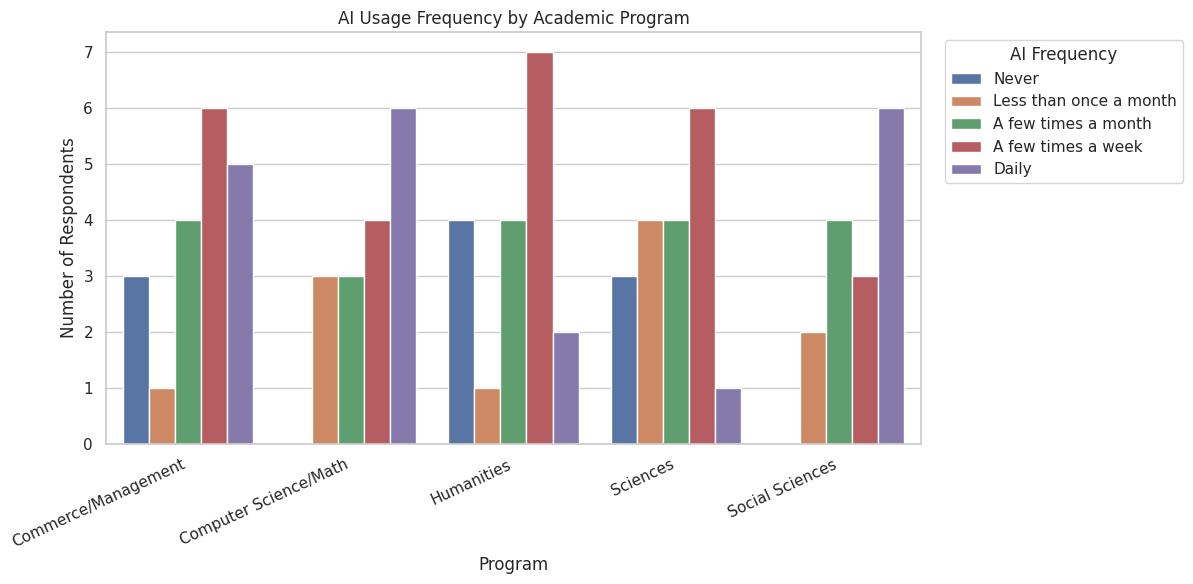

In [9]:
plot_df = ai_freq_program.reset_index().melt(id_vars="Program", var_name="AI Frequency", value_name="Count")

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="Program", y="Count", hue="AI Frequency", hue_order=frequency_order)
plt.title("AI Usage Frequency by Academic Program")
plt.xlabel("Program")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=25, ha="right")
plt.legend(title="AI Frequency", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Business-style insight:** Adoption differs by segment. Social Sciences and Computer Science/Math show the highest average frequency scores, while Sciences and Humanities are less consistent. In business terms, this suggests that adoption is shaped by segment context and perceived relevance, not simply by tool availability.

## 7. Finding 2: Confidence vs Trust

**Analyst question:** Does user confidence predict trust in the tool?

In [10]:
query = """
SELECT Confidence, Trust, COUNT(*) AS Count
FROM survey_data
GROUP BY Confidence, Trust
ORDER BY Confidence, Count DESC;
"""
confidence_trust_sql = sql(query)
confidence_trust_sql

,Confidence,Trust,Count
0,Extremely confident,Very trustworthy,5
1,Extremely confident,Trustworthy,5
2,Extremely confident,Somewhat trustworthy,1
3,Extremely confident,Not trustworthy,1
4,Moderately confident,Neutral,12
5,Moderately confident,Somewhat trustworthy,9
6,Moderately confident,Very trustworthy,1
7,Moderately confident,Not trustworthy,1
8,Not confident,Not trustworthy,5
9,Not confident,Neutral,4


In [11]:
confidence_trust = pd.crosstab(df["Confidence"], df["Trust"])
confidence_trust = confidence_trust.reindex(index=confidence_order, columns=trust_order, fill_value=0)
confidence_trust

Trust,Not trustworthy,Somewhat trustworthy,Neutral,Trustworthy,Very trustworthy
Confidence,,,,,
Not confident at all,3,0,0,0,0
Not confident,5,0,4,1,1
Slightly confident,2,7,5,2,1
Moderately confident,1,9,12,0,1
Very confident,2,5,2,9,2
Extremely confident,1,1,0,5,5


Correlation between Confidence Score and Trust Score: 0.461


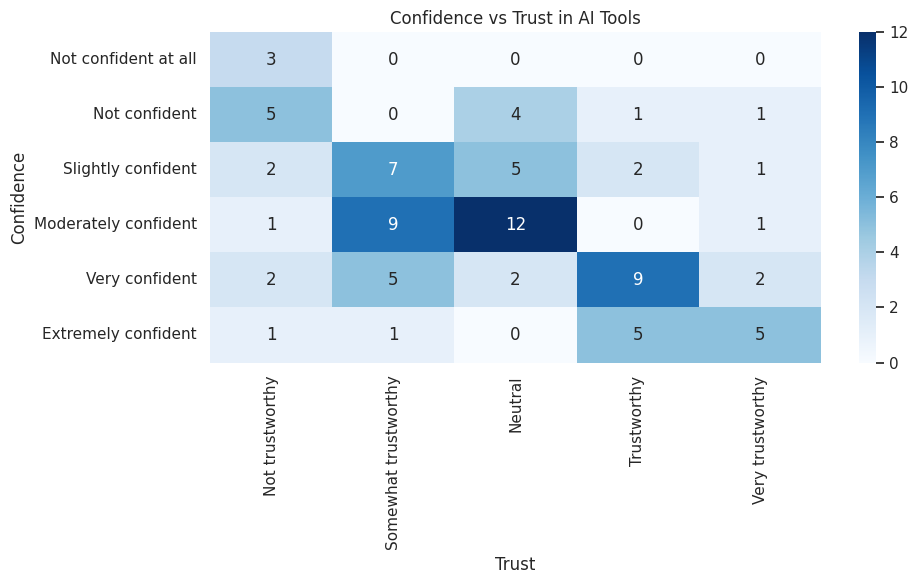

In [12]:
correlation = df[["Confidence Score", "Trust Score"]].corr().iloc[0, 1]
print(f"Correlation between Confidence Score and Trust Score: {correlation:.3f}")

plt.figure(figsize=(10, 6))
sns.heatmap(confidence_trust, annot=True, fmt="d", cmap="Blues")
plt.title("Confidence vs Trust in AI Tools")
plt.xlabel("Trust")
plt.ylabel("Confidence")
plt.tight_layout()
plt.show()

**Business-style insight:** Confidence and trust move together. This means trust is not only about the tool itself; it is also about the user's comfort and familiarity. For a business rolling out AI tools, training could increase trust by increasing confidence.

## 8. Finding 3: Instructor Guidance vs Guideline Clarity

**Analyst question:** Does communication from instructors reduce confusion about AI policy?

In [13]:
query = """
SELECT "Instructor Guidance", "Guideline Clarity", COUNT(*) AS Count
FROM survey_data
GROUP BY "Instructor Guidance", "Guideline Clarity"
ORDER BY "Instructor Guidance", Count DESC;
"""
guidance_clarity_sql = sql(query)
guidance_clarity_sql

,Instructor Guidance,Guideline Clarity,Count
0,"No, never",Very unclear,17
1,"No, never",Somewhat unclear,13
2,"No, never",Neutral,5
3,"No, never",Very clear,3
4,"No, never",Somewhat clear,2
5,"Not yet, but guidelines mentioned",Somewhat unclear,8
6,"Not yet, but guidelines mentioned",Neutral,3
7,"Not yet, but guidelines mentioned",Very clear,2
8,"Not yet, but guidelines mentioned",Somewhat clear,2
9,"Not yet, but guidelines mentioned",Very unclear,1


In [14]:
guidance_order = [
    "No, never",
    "Not yet, but guidelines mentioned",
    "Yes, in one course",
    "Yes, in multiple courses",
]

guidance_clarity = pd.crosstab(df["Instructor Guidance"], df["Guideline Clarity"])
guidance_clarity = guidance_clarity.reindex(index=guidance_order, columns=clarity_order, fill_value=0)
guidance_clarity

Guideline Clarity,Very unclear,Somewhat unclear,Neutral,Somewhat clear,Very clear
Instructor Guidance,,,,,
"No, never",17,13,5,2,3
"Not yet, but guidelines mentioned",1,8,3,2,2
"Yes, in one course",0,2,5,7,1
"Yes, in multiple courses",3,2,1,7,2


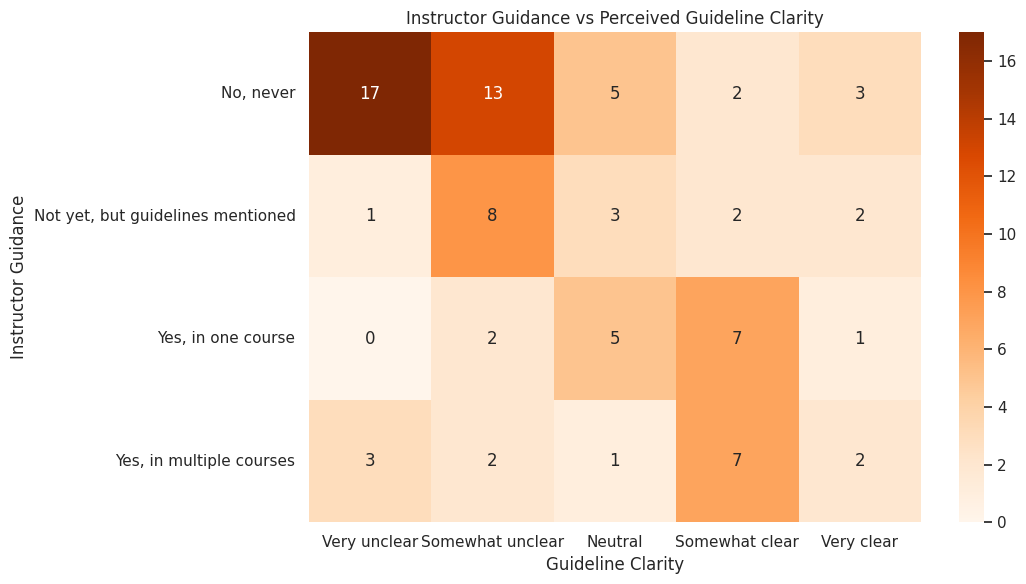

In [15]:
plt.figure(figsize=(11, 6))
sns.heatmap(guidance_clarity, annot=True, fmt="d", cmap="Oranges")
plt.title("Instructor Guidance vs Perceived Guideline Clarity")
plt.xlabel("Guideline Clarity")
plt.ylabel("Instructor Guidance")
plt.tight_layout()
plt.show()

In [16]:
no_guidance_df = df[df["Instructor Guidance"] == "No, never"]
no_guidance_unclear = no_guidance_df["Guideline Clarity"].isin(["Somewhat unclear", "Very unclear"]).sum()
no_guidance_total = len(no_guidance_df)

print(f"Students with no instructor guidance: {no_guidance_total}")
print(f"No-guidance students reporting unclear guidelines: {no_guidance_unclear}")
print(f"Share unclear among no-guidance students: {no_guidance_unclear / no_guidance_total:.1%}")

Students with no instructor guidance: 40
No-guidance students reporting unclear guidelines: 30
Share unclear among no-guidance students: 75.0%


**Primary insight:** Students who receive no guidance are much more likely to report unclear guidelines. In business terms, silence from leadership or managers creates inconsistent user behavior. The issue is not only user confusion; it is a communication and governance gap.

## 9. Finding 4: Daily Users and Learning Impact

**Analyst question:** Are heavy users reporting positive or negative outcomes?

In [17]:
query = """
SELECT "Learning Impact", COUNT(*) AS Count
FROM survey_data
WHERE "AI Frequency" = 'Daily'
GROUP BY "Learning Impact"
ORDER BY Count DESC;
"""
daily_learning_sql = sql(query)
daily_learning_sql

,Learning Impact,Count
0,"Yes, mostly positive",15
1,"Yes, mostly negative",3
2,"Yes, mixed positive and negative",2


In [18]:
daily_learning = df[df["AI Frequency"] == "Daily"]["Learning Impact"].value_counts().reset_index()
daily_learning.columns = ["Learning Impact", "Count"]
daily_learning

,Learning Impact,Count
0,"Yes, mostly positive",15
1,"Yes, mostly negative",3
2,"Yes, mixed positive and negative",2


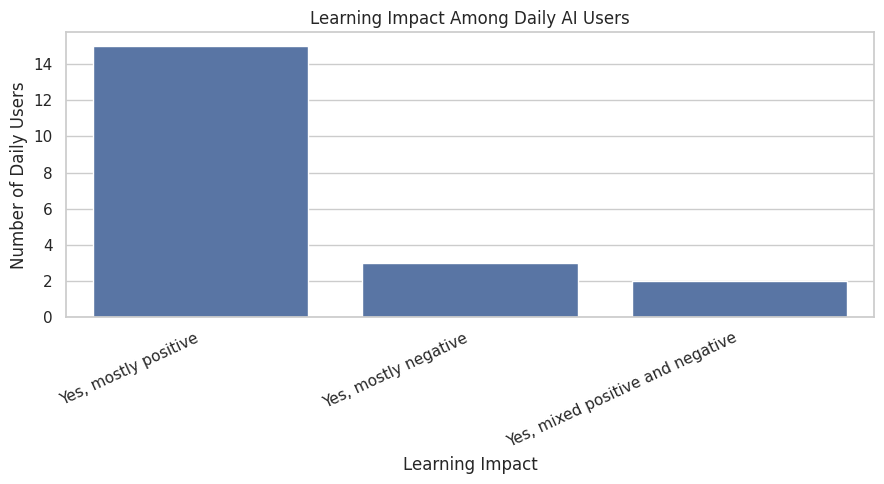

In [19]:
plt.figure(figsize=(9, 5))
sns.barplot(data=daily_learning, x="Learning Impact", y="Count", color="C0")
plt.title("Learning Impact Among Daily AI Users")
plt.xlabel("Learning Impact")
plt.ylabel("Number of Daily Users")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

**Business-style insight:** Daily use does not automatically mean negative impact. Most daily users report a mostly positive learning impact. For organizations, this suggests that heavy usage should not automatically be treated as misuse; the focus should be on responsible use, guidance, and outcome quality.

## 10. Finding 5: Living Situation vs AI Frequency

**Analyst question:** Is AI usage affected by location or access context?

In [20]:
query = """
SELECT "Living Situation", "AI Frequency", COUNT(*) AS Count
FROM survey_data
GROUP BY "Living Situation", "AI Frequency"
ORDER BY "Living Situation", Count DESC;
"""
living_frequency_sql = sql(query)
living_frequency_sql

,Living Situation,AI Frequency,Count
0,Off campus outside Mississauga,A few times a week,13
1,Off campus outside Mississauga,Daily,6
2,Off campus outside Mississauga,Less than once a month,5
3,Off campus outside Mississauga,A few times a month,4
4,Off campus outside Mississauga,Never,3
5,Off campus within Mississauga,Daily,8
6,Off campus within Mississauga,A few times a month,7
7,Off campus within Mississauga,A few times a week,5
8,Off campus within Mississauga,Never,3
9,Off campus within Mississauga,Less than once a month,3


In [21]:
living_freq = pd.crosstab(df["Living Situation"], df["AI Frequency"])
living_freq = living_freq.reindex(columns=frequency_order, fill_value=0)
living_freq

AI Frequency,Never,Less than once a month,A few times a month,A few times a week,Daily
Living Situation,,,,,
Off campus outside Mississauga,3,5,4,13,6
Off campus within Mississauga,3,3,7,5,8
On campus,4,3,8,8,6


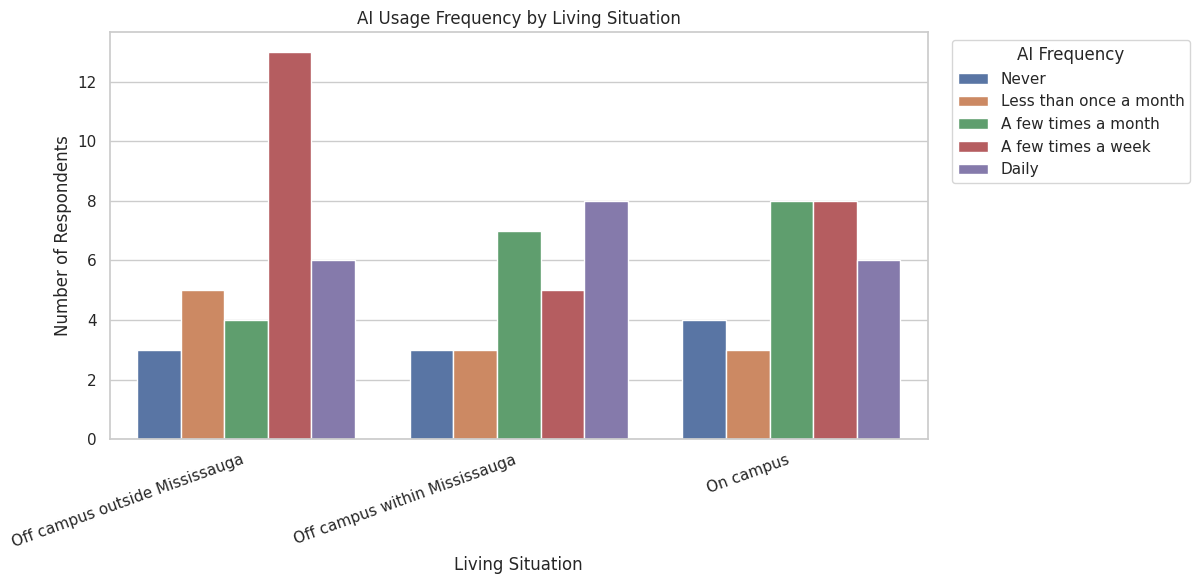

In [22]:
living_plot = living_freq.reset_index().melt(id_vars="Living Situation", var_name="AI Frequency", value_name="Count")

plt.figure(figsize=(12, 6))
sns.barplot(data=living_plot, x="Living Situation", y="Count", hue="AI Frequency", hue_order=frequency_order)
plt.title("AI Usage Frequency by Living Situation")
plt.xlabel("Living Situation")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=20, ha="right")
plt.legend(title="AI Frequency", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Business-style insight:** Living situation does not appear to meaningfully explain AI usage. This suggests that adoption is more strongly related to attitudes, program context, confidence, and guidance than to physical proximity to campus.

## 11. Program-Level Scorecard

This scorecard summarizes average scores by program. This is useful for stakeholder communication because it turns multiple survey measures into a segment comparison.

In [23]:
program_scorecard = (
    df.groupby("Program")
    .agg(
        Respondents=("#", "count"),
        Avg_AI_Frequency=("AI Frequency Score", "mean"),
        Avg_Confidence=("Confidence Score", "mean"),
        Avg_Trust=("Trust Score", "mean"),
        Avg_Guideline_Clarity=("Guideline Clarity Score", "mean"),
        Avg_Preparedness=("Preparedness Score", "mean"),
        Avg_Independence=("Independence Score", "mean"),
        No_Guidance_Rate=("Instructor Guidance", lambda x: (x == "No, never").mean()),
        Positive_Learning_Rate=("Learning Impact", lambda x: (x == "Yes, mostly positive").mean()),
    )
    .round(2)
    .sort_values("Avg_AI_Frequency", ascending=False)
)
program_scorecard

,Respondents,Avg_AI_Frequency,Avg_Confidence,Avg_Trust,Avg_Guideline_Clarity,Avg_Preparedness,Avg_Independence,No_Guidance_Rate,Positive_Learning_Rate
Program,,,,,,,,,
Social Sciences,15,2.87,3.13,2.07,0.47,1.67,2.33,0.80,0.40
Computer Science/Math,16,2.81,3.12,2.44,2.06,2.94,2.62,0.12,0.44
Commerce/Management,19,2.47,3.42,1.84,1.63,1.63,1.68,0.58,0.42
Humanities,18,2.11,2.67,1.44,1.72,2.06,2.06,0.50,0.56
Sciences,18,1.89,2.44,1.56,2.06,1.61,2.06,0.33,0.50


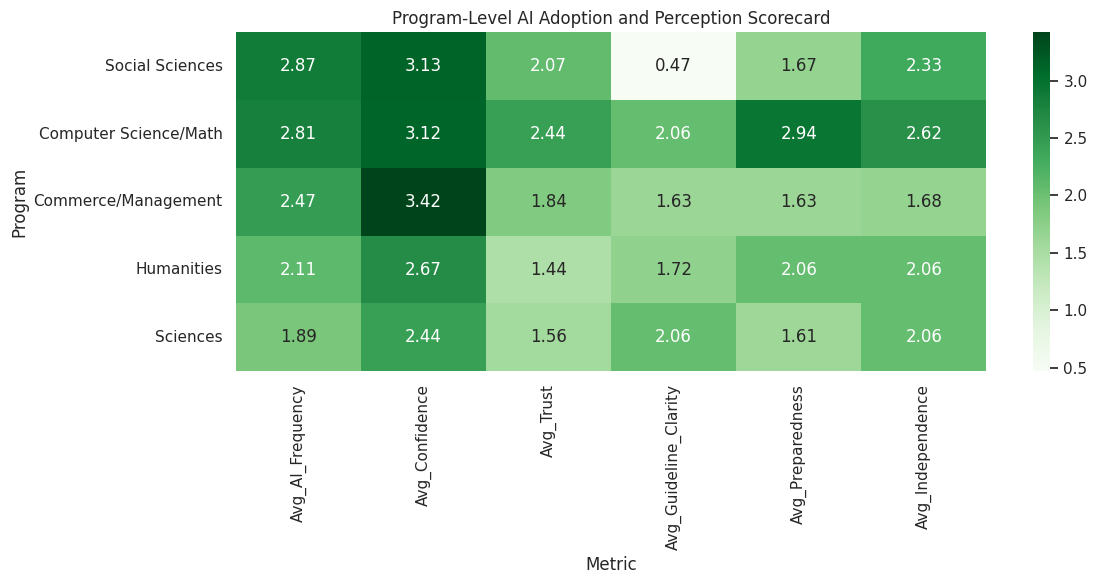

In [24]:
score_cols = ["Avg_AI_Frequency", "Avg_Confidence", "Avg_Trust", "Avg_Guideline_Clarity", "Avg_Preparedness", "Avg_Independence"]

plt.figure(figsize=(12, 6))
sns.heatmap(program_scorecard[score_cols], annot=True, fmt=".2f", cmap="Greens")
plt.title("Program-Level AI Adoption and Perception Scorecard")
plt.xlabel("Metric")
plt.ylabel("Program")
plt.tight_layout()
plt.show()

## 12. Extreme Confidence Segments

This query isolates the most confident and least confident users. This is similar to segmenting customers into advocates and skeptics.

In [25]:
query = """
SELECT Program, "AI Frequency", "Tools Used", Uses, Confidence, Trust, "Guideline Clarity", 
       "Instructor Guidance", "Learning Impact", Preparedness, Independence
FROM survey_data
WHERE Confidence IN ('Extremely confident', 'Not confident at all', 'Not confident')
ORDER BY Confidence, Program;
"""
extreme_confidence_sql = sql(query)
extreme_confidence_sql

,Program,AI Frequency,Tools Used,Uses,Confidence,Trust,Guideline Clarity,Instructor Guidance,Learning Impact,Preparedness,Independence
0,Commerce/Management,Daily,"ChatGPT, Copilot","Brainstorming, writing assistance, studying/re...",Extremely confident,Trustworthy,Somewhat unclear,"Not yet, but guidelines mentioned","Yes, mostly positive",Very prepared,Somewhat supports
1,Commerce/Management,Daily,"ChatGPT, QuillBot, Grammarly",All of the above,Extremely confident,Trustworthy,Very unclear,"No, never","Yes, mostly positive",Prepared,Somewhat supports
2,Commerce/Management,Daily,"ChatGPT, QuillBot",All of the above,Extremely confident,Trustworthy,Very unclear,"No, never","Yes, mostly negative",Somewhat prepared,Somewhat limits
3,Commerce/Management,Daily,Grammarly,"Studying, Brainstorming, Editing",Extremely confident,Not trustworthy,Somewhat unclear,"No, never","Yes, mostly positive",Very prepared,Somewhat supports
4,Commerce/Management,Never,"Copilot, ChatGPT",Writing,Extremely confident,Very trustworthy,Neutral,"No, never","Yes, mixed positive and negative",Not prepared,Strongly limits
5,Computer Science/Math,Daily,"ChatGPT, Copilot","Coding help, clarifying concepts, debugging",Extremely confident,Very trustworthy,Somewhat clear,"Yes, in multiple courses","Yes, mostly positive",Very prepared,Somewhat supports
6,Computer Science/Math,Daily,"Copilot, ChatGPT","Debugging, explanations, practice problems",Extremely confident,Trustworthy,Somewhat clear,"Yes, in multiple courses","Yes, mostly positive",Very prepared,Somewhat supports
7,Computer Science/Math,Less than once a month,Grammarly,Coding,Extremely confident,Somewhat trustworthy,Neutral,"Yes, in one course","Yes, mixed positive and negative",Somewhat prepared,Neutral
8,Humanities,Never,"ChatGPT, Grammarly","Studying, Clarifying concepts",Extremely confident,Trustworthy,Somewhat clear,"Yes, in multiple courses","Yes, mixed positive and negative",Very prepared,Somewhat supports
9,Social Sciences,Daily,ChatGPT,All of the above,Extremely confident,Very trustworthy,Very unclear,"No, never","Yes, mostly positive",Very prepared,Strongly supports


**Business-style insight:** Segmenting extreme users helps identify what separates highly confident adopters from skeptical users. This approach can be used in real business contexts to compare champions, average users, and resistant users during technology rollouts.

## 13. Final Analyst Summary

**Overall story:**  
AI is already widely adopted among students, but adoption is uneven across segments and shaped heavily by confidence, trust, and guidance. The strongest operational gap is communication: students who receive little or no instructor guidance are more likely to perceive AI rules as unclear. Frequent users mostly report positive learning impacts, suggesting that the main problem is not simply overuse. The more important issue is whether institutions provide clear expectations, examples, and training.

**Business translation:**  
This project mirrors a common organizational challenge: when a new technology spreads faster than policy, users create their own rules. Better communication, training, and segment-specific guidance can reduce uncertainty and improve responsible adoption.

## 14. Recommendations

1. **Create clear usage guidelines:** Provide concrete examples of acceptable and unacceptable AI use.
2. **Target low-confidence users:** Confidence is linked to trust, so training should focus on skill-building and verification habits.
3. **Segment guidance by user group:** Different programs show different adoption patterns, so one generic policy may not fit all users.
4. **Treat high usage as a signal, not a problem:** Heavy users often report positive outcomes; assess quality and responsible use rather than frequency alone.
5. **Close the communication gap:** Lack of guidance is associated with unclear expectations, which can lead to anxiety, inconsistent behavior, and hidden use.